# FOV Screening: pick interesting positions before a stim run

Loads the four corner positions you set manually in napari-MM (saved as
``corner_positions.json``), interpolates a 10x10 grid of FOVs across the
spanned region, acquires one frame at each in both imaging channels, and
runs the same segmentation + feature-extraction pipeline as the stim
experiments. After acquisition you filter cells by area and per-channel
mean expression, preview cropped matches, and export the FOV positions
that still contain at least one matching cell — ready to drop into the
stim notebook for the actual run.

Same Moench scope, same imaging channels, same processing pipeline as
``23_random_stim_per_cell_14px_patches``.

In [2]:
import os
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from faro.core.data_structures import (
    PowerChannel,
    RTMSequence,
    SegmentationMethod,
    combine,
)
import faro.core.utils as utils

## Microscope

Same Moench setup as the other notebooks (2x2 binning + centered ROI
applied automatically in ``Moench.init_scope``).

In [3]:
from faro.microscope.pertzlab.moench import Moench

mic = Moench(None)
mic.mmc.setChannelGroup("TTL_ERK")

## Configuration

* ``CORNER_JSON_PATH`` -- the four-corner JSON saved from napari-MM.
  Format is whatever ``Position.model_dump()`` produces (``x``, ``y``,
  ``z``, ``name`` keys); we only use ``x``/``y``.
* ``GRID_N`` -- side length of the FOV grid (10 = 100 FOVs).
* ``base_path`` / ``experiment_name`` -- where the screening data lands.
  Use a separate folder from the stim experiment so post-processing
  doesn't mix them up.

In [26]:
# --- Configuration 
CORNER_JSON_PATH = r"Z:\lhinder\data\rtm_mm_data\exp_427\corner-positions.json"
GRID_N = 25  # 10x10 -> 100 FOVs

base_path = r"Z:\lhinder\data\rtm_mm_data\exp_427"
experiment_name = "fov_screening"
path = os.path.join(base_path, experiment_name)

# Same two imaging channels as the stim notebooks (channel 0 is what
# cellpose segments on).
imaging_channels = (
    PowerChannel(config="mScarlet3", exposure=100, group="TTL_ERK", power=50),
    PowerChannel(config="miRFP",     exposure=1000, group="TTL_ERK", power=99),
)

print(f"output: {path}")
print(f"corners: {CORNER_JSON_PATH}")

output: Z:\lhinder\data\rtm_mm_data\exp_427\fov_screening
corners: Z:\lhinder\data\rtm_mm_data\exp_427\corner-positions.json


## Build the FOV grid

Reads the corner JSON and builds a ``GRID_N x GRID_N`` axis-aligned
grid by linspace-ing ``x`` and ``y`` between the bounding-box of the
corners. This ignores any rotation in the manually set region — fine
for a first-pass screen; a proper bilinear-interpolation version can
go in once we move past the simple bounding-box approximation.

In [27]:
with open(CORNER_JSON_PATH, "r") as f:
    corners = json.load(f)

xs = [c["x"] for c in corners]
ys = [c["y"] for c in corners]
x_grid = np.linspace(min(xs), max(xs), GRID_N)
y_grid = np.linspace(min(ys), max(ys), GRID_N)

# Row-major: FOV 0 is top-left (min y, min x), FOV GRID_N is start of
# the second row, ..., FOV GRID_N*GRID_N-1 is bottom-right.
fov_positions = []
for j, y in enumerate(y_grid):
    for i, x in enumerate(x_grid):
        fov_positions.append(
            utils.FovPosition(
                x=float(x), y=float(y), z=None, name=f"r{j:02d}c{i:02d}"
            )
        )

print(f"{len(fov_positions)} FOVs covering "
      f"x=[{min(xs):.0f}..{max(xs):.0f}], y=[{min(ys):.0f}..{max(ys):.0f}]")

625 FOVs covering x=[-15684..-6889], y=[9005..14243]


## Pipeline

Same components as the stim notebooks: CellposeV4 on channel 0,
``FE_ErkKtr`` for per-cell area and per-channel mean intensities,
``TrackerTrackpy`` (single-frame so it just initialises and exits).
No stimulator and no ref channel — this is a one-shot screen.

In [28]:
from faro.tracking.trackpy import TrackerTrackpy
from faro.feature_extraction.erk_ktr import FE_ErkKtr
from faro.segmentation.cellpose_v4 import CellposeV4

segmentators = [
    SegmentationMethod(
        name="labels",
        segmentation_class=CellposeV4(),
        use_channel=0,
        save_tracked=True,
    )
]
feature_extractor = FE_ErkKtr("labels")
tracker = TrackerTrackpy(search_range=50)

from faro.core.pipeline import ImageProcessingPipeline

pipeline = ImageProcessingPipeline(
    storage_path=path,
    segmentators=segmentators,
    feature_extractor=feature_extractor,
    tracker=tracker,
    stimulator=None,
    feature_extractor_ref=None,
)

from faro.core.controller import Controller
from faro.core.writers import OmeZarrWriter

writer = OmeZarrWriter(storage_path=path)

Directory Z:\lhinder\data\rtm_mm_data\exp_427\fov_screening\tracks already exists


## Build events

Single timepoint, two imaging channels, no stim, no ref. ``time_per_fov``
is set generously so all 100 FOVs fall in one batch — but the FOV
batching code handles overflow correctly if your settings push past the
interval.

In [29]:
phase = RTMSequence(
    time_plan={"interval": 1, "loops": 1},   # single timepoint
    stage_positions=fov_positions,
    channels=imaging_channels,
    stim_channels=(),
    stim_frames=[],
    ref_channels=(),
    ref_frames=[],
    rtm_metadata={
        "phase_name": "FovScreening",
        "phase_id": 0,
        "treatment_name": "FOV screening pre-flight",
    },
)

events = combine(phase, axis="t")
events = utils.apply_fov_batching(events, time_per_fov=2.0)

print(f"Total events: {len(events)}  /  FOVs: {len(fov_positions)}")

Total events: 625  /  FOVs: 625


## Run

Same controller as the stim notebooks. ``stim_mode`` defaults to
``"current"`` which is irrelevant here (no stim events) but the
controller still requires it to be set.

In [30]:
ctrl = Controller(mic, pipeline, writer=writer)
ctrl.validate_events(events)
ctrl.run_experiment(events, stim_mode="current")
ctrl.finish_experiment()
utils.generate_exp_data_from_tracks(path)
exp_data_path = os.path.join(path, "exp_data.parquet")
df_exp = pd.read_parquet(exp_data_path)
print(f"acquired {df_exp['fov'].nunique()} FOVs, {len(df_exp)} cell rows")

C:\Users\lh21x018\Documents\code\faro\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\lh21x018\Documents\code\faro\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\lh21x018\Documents\code\faro\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\lh21x018\Documents\code\faro\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
C:\Users\lh21x018\Documents\code\faro\faro\segmentation\cellpose_v4.py:55: U

acquired 606 FOVs, 6581 cell rows


## Overview: 10x10 grid for both channels

Reads the OME-Zarr store and tiles each FOV's first frame into a single
``GRID_N x GRID_N`` collage per channel. Each tile is downsampled to
keep the figure light.

zarr shape: (1, 625, 2, 800, 1024)


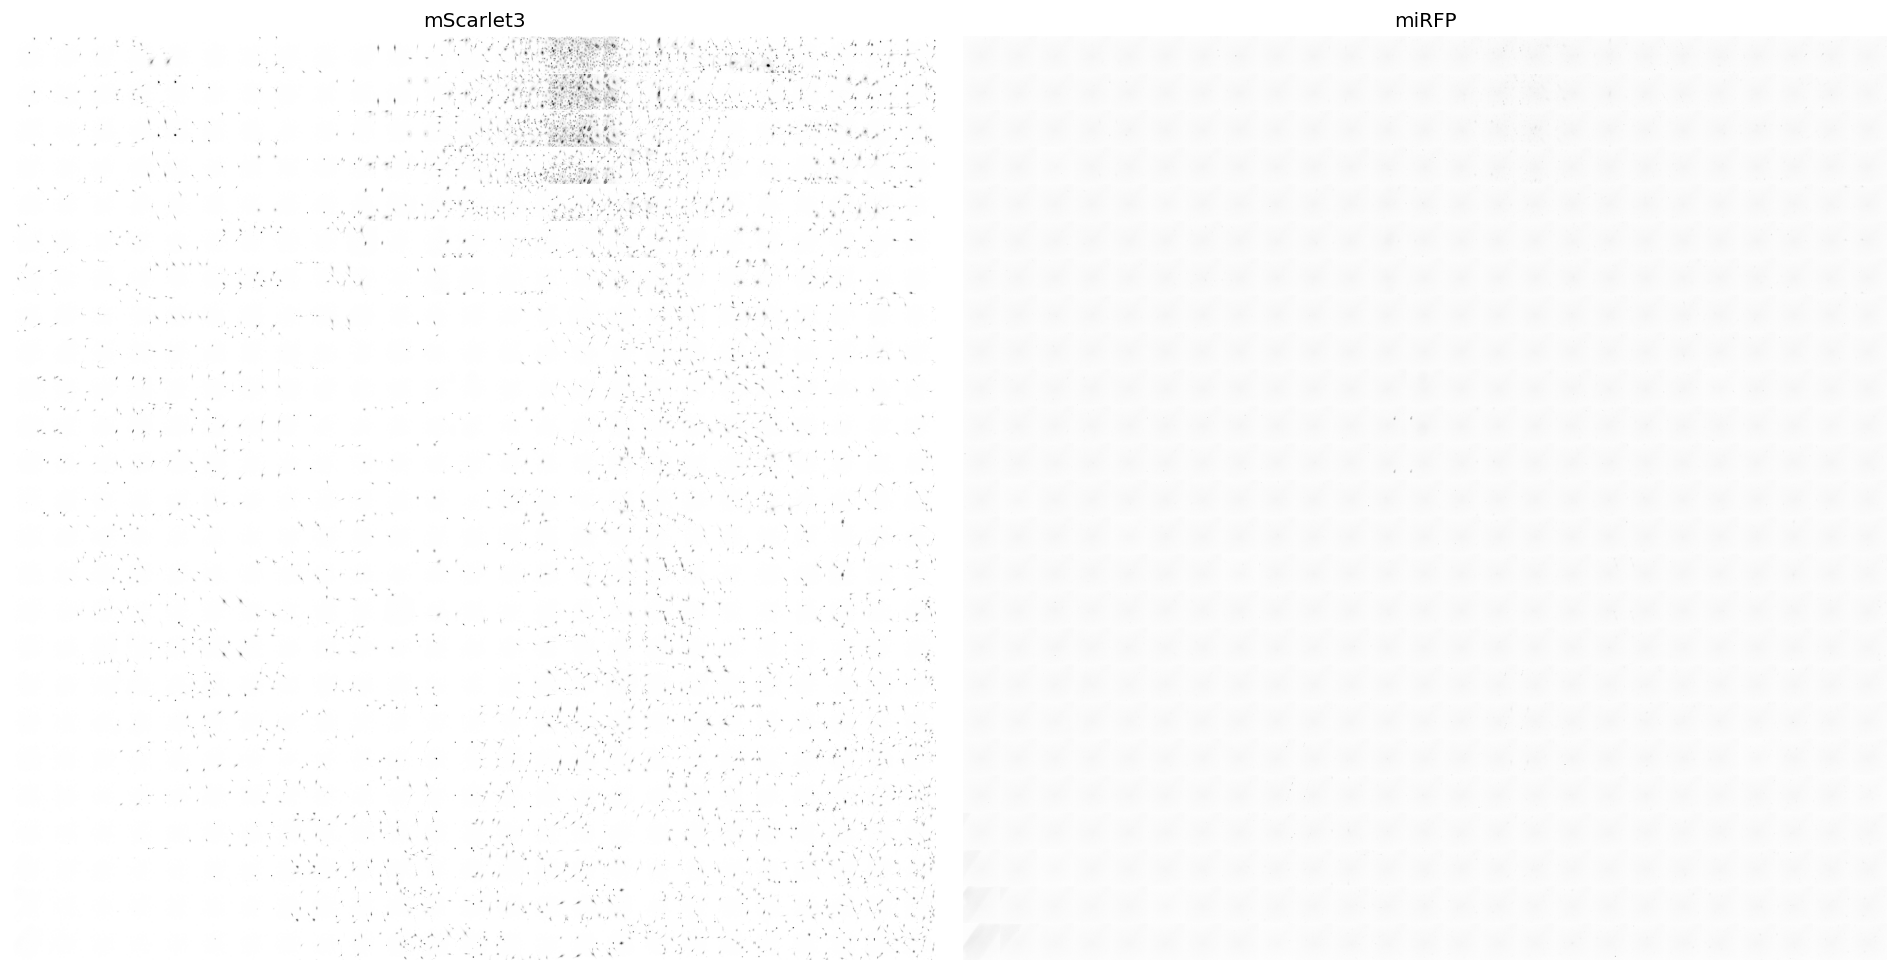

In [31]:
import zarr

zarr_path = os.path.join(path, "acquisition.ome.zarr")
root = zarr.open(zarr_path, mode="r")
arr = root["0"]  # (t, p, c, y, x) — t first, p second
print("zarr shape:", arr.shape)

n_t, n_pos, n_c, h, w = arr.shape
n_ch_show = min(n_c, 2)

THUMB = 64

fig, axs = plt.subplots(1, n_ch_show, figsize=(8 * n_ch_show, 8), dpi=120)
if n_ch_show == 1:
    axs = [axs]

for ch in range(n_ch_show):
    collage = np.zeros((GRID_N * THUMB, GRID_N * THUMB), dtype=np.float32)
    for p in range(min(n_pos, GRID_N * GRID_N)):
        j, i = divmod(p, GRID_N)
        frame = np.asarray(arr[0, p, ch])     # t=0, position p, channel ch
        sy = max(1, frame.shape[0] // THUMB)
        sx = max(1, frame.shape[1] // THUMB)
        thumb = frame[::sy, ::sx][:THUMB, :THUMB]
        ty, tx = thumb.shape
        collage[j * THUMB:j * THUMB + ty, i * THUMB:i * THUMB + tx] = thumb
    axs[ch].imshow(collage, cmap="gray_r")
    axs[ch].set_title(imaging_channels[ch].config)
    axs[ch].axis("off")
plt.tight_layout()
plt.show()

## Filter cells by area + mean expression

``df_exp`` columns of interest (from ``FE_ErkKtr``):

* ``area`` -- cell area in pixels
* ``mean_intensity_C0_nuc`` -- nuclear mean in channel 0 (mScarlet3)
* ``mean_intensity_C1_nuc`` -- nuclear mean in channel 1 (miRFP)

Adjust the ranges below; the cell prints how many cells/FOVs survive
and shows a small grid of cropped cells that pass.

In [68]:
df_exp['fov_col'] = df_exp['fov']%25
df_exp['fov_row'] = df_exp['fov']%25

df_x = df_exp.copy()
df_x['good'] = (df_exp['fov_col']%2==0) & (df_exp['fov_col']%2==0)

In [69]:
df_exp['fov_row'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24], dtype=uint16)

In [70]:
df_x['fov_row'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24], dtype=uint16)

In [73]:
df_x = df_x[df_x['good']]

In [76]:
df_exp_copy = df_exp.copy()

In [77]:
df_exp = df_x

matching cells: 38  /  FOVs hit: 32


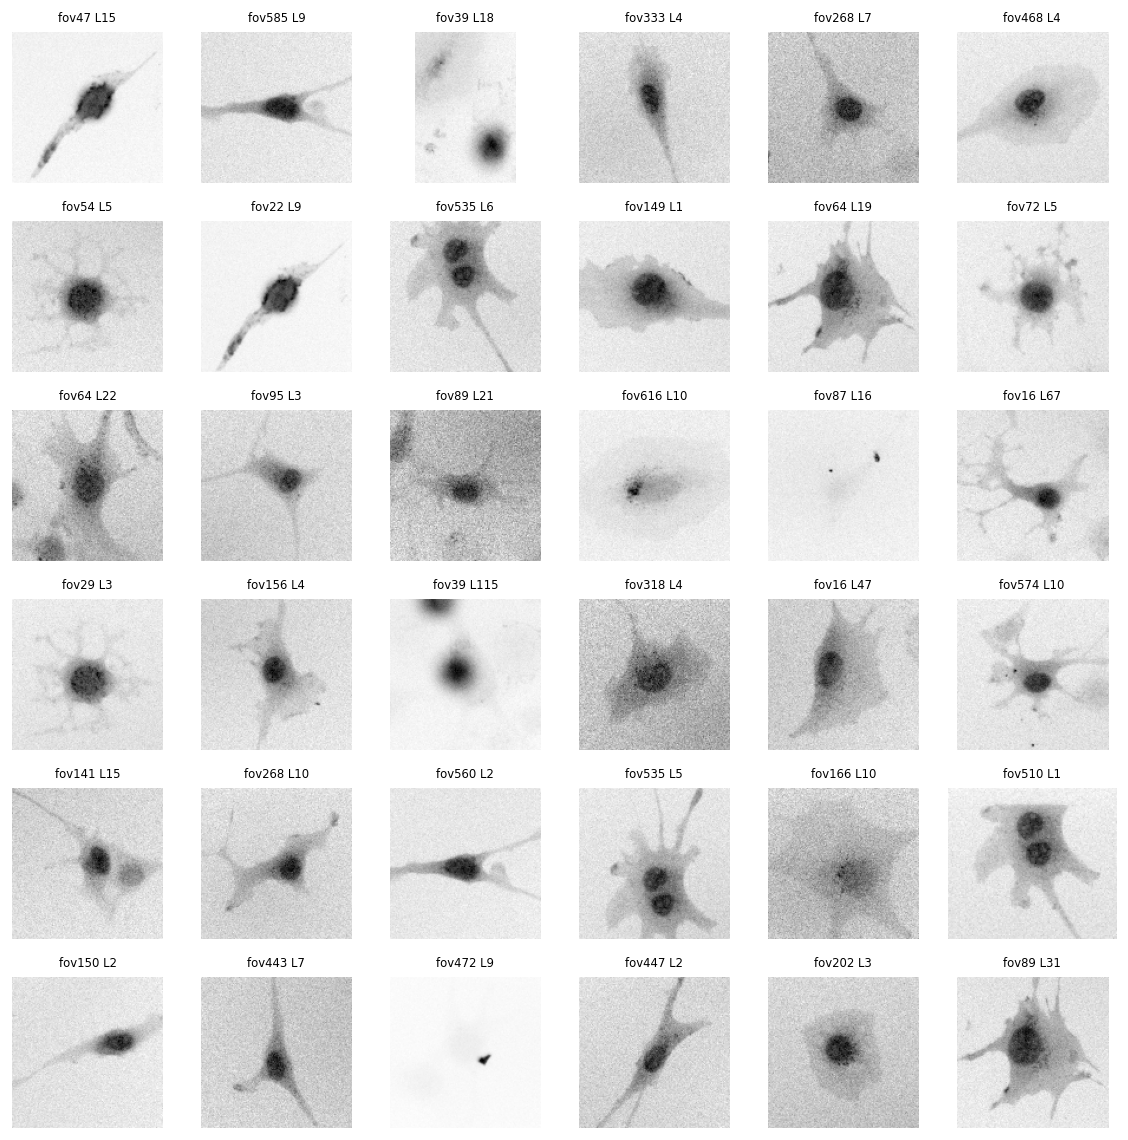

In [78]:
# --- Filter ranges (edit and re-run) ---
# FE_ErkKtr renames `area` -> `area_nuc`. The pipeline's positional
# columns `x` / `y` carry image-row / image-col indices respectively
# (the legacy rename of skimage's `centroid-0` / `centroid-1`), which
# is what we use for cropping below.
AREA_MIN, AREA_MAX           = 2000, 10000
C0_MEAN_MIN, C0_MEAN_MAX     = 100, 65535     # mScarlet3 nuclear mean
C1_MEAN_MIN, C1_MEAN_MAX     = 800, 65535     # miRFP nuclear mean

mask = (
    df_exp["area_nuc"].between(AREA_MIN, AREA_MAX)
    & df_exp["mean_intensity_C0_nuc"].between(C0_MEAN_MIN, C0_MEAN_MAX)
    & df_exp["mean_intensity_C1_nuc"].between(C1_MEAN_MIN, C1_MEAN_MAX)
)
df_match = df_exp[mask].copy()
print(f"matching cells: {len(df_match)}  /  FOVs hit: {df_match['fov'].nunique()}")

# --- Crop preview ---
CROP = 128
N_PREVIEW = min(36, len(df_match))
if N_PREVIEW:
    cols = 6
    rows = int(np.ceil(N_PREVIEW / cols))
    fig, axs = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.6), dpi=120)
    axs = np.atleast_1d(axs).reshape(rows, cols)
    sample = df_match.sample(N_PREVIEW, random_state=0).reset_index(drop=True)
    for k, row in sample.iterrows():
        r, c = divmod(k, cols)
        p = int(row["fov"])
        # df["x"] = image row, df["y"] = image col (pipeline rename quirk).
        row_idx, col_idx = int(row["x"]), int(row["y"])
        # Channel 0 (segmentation channel) for the preview thumbnails
        frame = np.asarray(arr[0, p, 1])
        y0 = max(0, row_idx - CROP // 2)
        y1 = min(frame.shape[0], row_idx + CROP // 2)
        x0 = max(0, col_idx - CROP // 2)
        x1 = min(frame.shape[1], col_idx + CROP // 2)
        axs[r, c].imshow(frame[y0:y1, x0:x1], cmap="gray_r")
        axs[r, c].set_title(f"fov{p} L{int(row['label'])}", fontsize=7)
        axs[r, c].axis("off")
    for k in range(N_PREVIEW, rows * cols):
        r, c = divmod(k, cols)
        axs[r, c].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("(no preview — adjust filters)")


## Save filtered FOV positions

Group filtered cells by FOV; FOVs with at least one match are exported
as ``filtered_positions.json`` next to the screening output. The format
mirrors the napari-MM corner JSON (``x``, ``y``, ``z``, ``name``) so it
can be loaded directly by ``utils.generate_fov_positions`` or pasted
into the stim notebook's ``base_path``.

In [79]:
hit_fov_idx = sorted(df_match["fov"].unique().tolist())
hit_positions = [
    {
        "x": fov_positions[p].x,
        "y": fov_positions[p].y,
        "z": fov_positions[p].z,
        "name": fov_positions[p].name,
    }
    for p in hit_fov_idx
]

out_json = os.path.join(path, "filtered_positions.json")
with open(out_json, "w") as f:
    json.dump(hit_positions, f, indent=2)

print(f"kept {len(hit_positions)}/{len(fov_positions)} FOVs")
print(f"wrote {out_json}")

kept 32/625 FOVs
wrote Z:\lhinder\data\rtm_mm_data\exp_427\fov_screening\filtered_positions.json
